In [1]:
from Bio import Entrez, SeqIO
from Bio.SeqUtils import gc_fraction
import matplotlib.pyplot as plt

Entrez.email = "jawad.edu45@gmail.com" 

print("Setup complete")

Setup complete


In [2]:
from Bio import SeqIO
import os

folders = ["BRCA_dataset", "TP53_dataset", "EGFR_dataset", "MYC_dataset", "APOE_dataset"]

gene_sequences = []
gene_names = []

for folder in folders:
    file_path = f"{folder}/ncbi_dataset/data/gene.fna"
    if os.path.exists(file_path):
        
        records = list(SeqIO.parse(file_path, "fasta"))
        if records:
            record = records[0] 
            gene_sequences.append(record)
            gene_names.append(folder.replace("_dataset", ""))
            print(f"Loaded: {record.id} from {folder}")
            print(f"Total transcripts in file: {len(records)} - Using first one")
        else:
            print(f"Error: No sequences found in {folder}")
    else:
        print(f"Error: {file_path} not found")

print(f"\nTotal genes loaded: {len(gene_sequences)}")

Loaded: NC_000017.11:c43170327-43044295 from BRCA_dataset
Total transcripts in file: 2 - Using first one
Loaded: NC_000017.11:c7687490-7668421 from TP53_dataset
Total transcripts in file: 2 - Using first one
Loaded: NC_000007.14:55019017-55211628 from EGFR_dataset
Total transcripts in file: 2 - Using first one
Loaded: NC_000008.11:127735434-127742951 from MYC_dataset
Total transcripts in file: 2 - Using first one
Loaded: NC_000019.10:44905796-44909393 from APOE_dataset
Total transcripts in file: 2 - Using first one

Total genes loaded: 5


BRCA: GC = 44.10%, Length = 126033 bp
TP53: GC = 49.38%, Length = 19070 bp
EGFR: GC = 44.57%, Length = 192612 bp
MYC: GC = 51.53%, Length = 7518 bp
APOE: GC = 61.06%, Length = 3598 bp


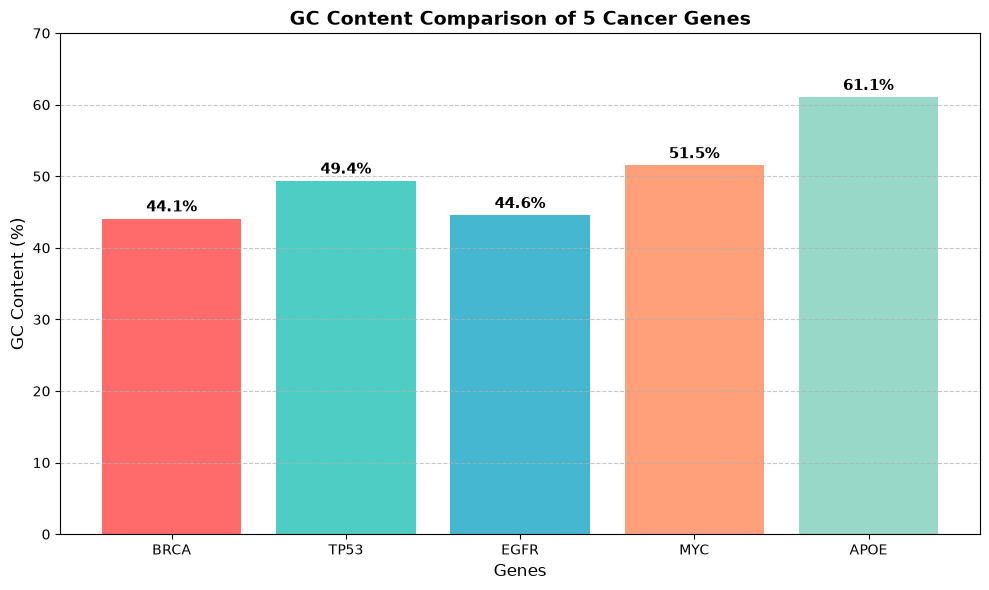

In [3]:
import matplotlib.pyplot as plt
from Bio.SeqUtils import gc_fraction

gc_contents = []


for i, record in enumerate(gene_sequences):
    gc = gc_fraction(record.seq) * 100 
    gc_contents.append(gc)
    print(f"{gene_names[i]}: GC = {gc:.2f}%, Length = {len(record.seq)} bp")


plt.figure(figsize=(10, 6))
bars = plt.bar(gene_names, gc_contents, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8'])
plt.ylabel('GC Content (%)', fontsize=12)
plt.xlabel('Genes', fontsize=12)
plt.title('GC Content Comparison of 5 Cancer Genes', fontsize=14, fontweight='bold')
plt.ylim(0, 70) 


for bar, gc in zip(bars, gc_contents):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{gc:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Total proteins loaded: 5

Columns available:
['Entry', 'Reviewed', 'Entry Name', 'Protein names', 'Gene Names', 'Organism', 'Length']

First 5 rows:
             Gene Names  Length
0  EGFR ERBB ERBB1 HER1    1210
1           MYC BHLHE39     454
2                  APOE     317
3              TP53 P53     393
4           BRCA1 RNF53    1863


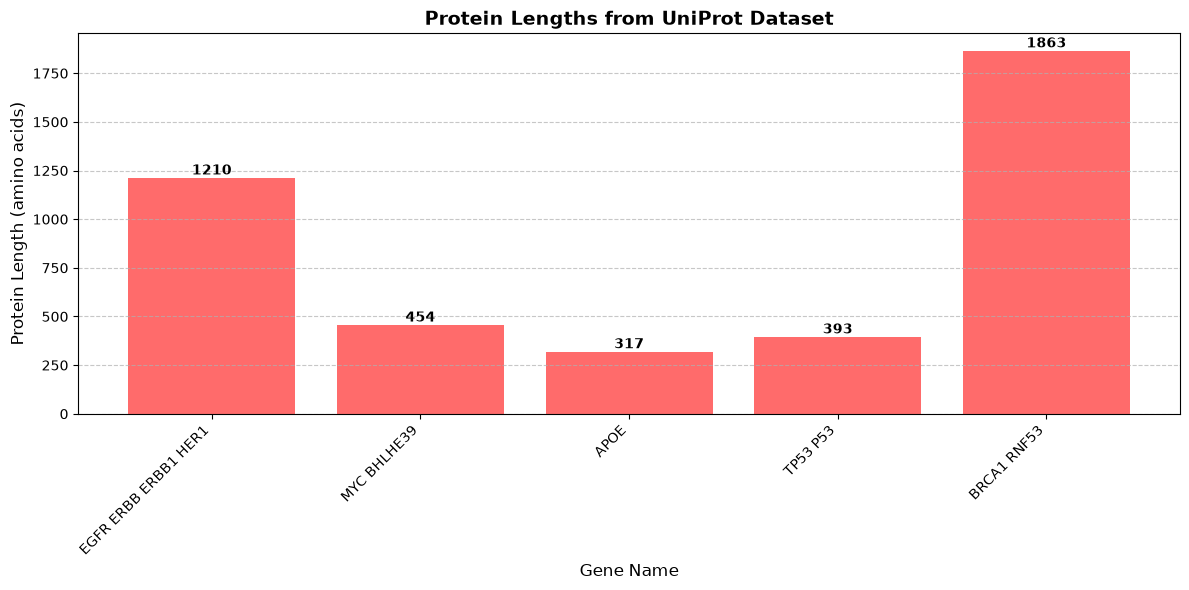


=== Data Statistics ===
count       5.000000
mean      847.400000
std       671.842467
min       317.000000
25%       393.000000
50%       454.000000
75%      1210.000000
max      1863.000000
Name: Length, dtype: float64

=== Sorted by Length ===
             Gene Names  Length
4           BRCA1 RNF53    1863
0  EGFR ERBB ERBB1 HER1    1210
1           MYC BHLHE39     454
3              TP53 P53     393
2                  APOE     317


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import glob


tsv_files = glob.glob('uniprotkb_accession_*.tsv')


df_list = []
for file in tsv_files:
    temp_df = pd.read_csv(file, sep='\t')
    df_list.append(temp_df)
    
df = pd.concat(df_list, ignore_index=True)


print("Total proteins loaded:", len(df))
print("\nColumns available:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df[['Gene Names', 'Length']].head())


plt.figure(figsize=(12, 6))
plt.bar(df['Gene Names'], df['Length'], color='#FF6B6B')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Protein Length (amino acids)', fontsize=12)
plt.xlabel('Gene Name', fontsize=12)
plt.title('Protein Lengths from UniProt Dataset', fontsize=14, fontweight='bold')


for i, length in enumerate(df['Length']):
    plt.text(i, length + 20, str(length), ha='center', fontsize=10, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


print("\n=== Data Statistics ===")
print(df['Length'].describe())
print("\n=== Sorted by Length ===")
print(df[['Gene Names', 'Length']].sort_values('Length', ascending=False))

C:\Users\Ahmad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


=== TASK 1: GC Content Distribution ===
   Gene  GC_Content  Sequence_Length
0  BRCA   44.097181           126033
1  TP53   49.375983            19070
2  EGFR   44.568355           192612
3   MYC   51.529662             7518
4  APOE   61.061701             3598


C:\Users\Ahmad\AppData\Local\Temp\ipykernel_8300\3319109620.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gc_df, x='Gene', y='GC_Content', palette='viridis')


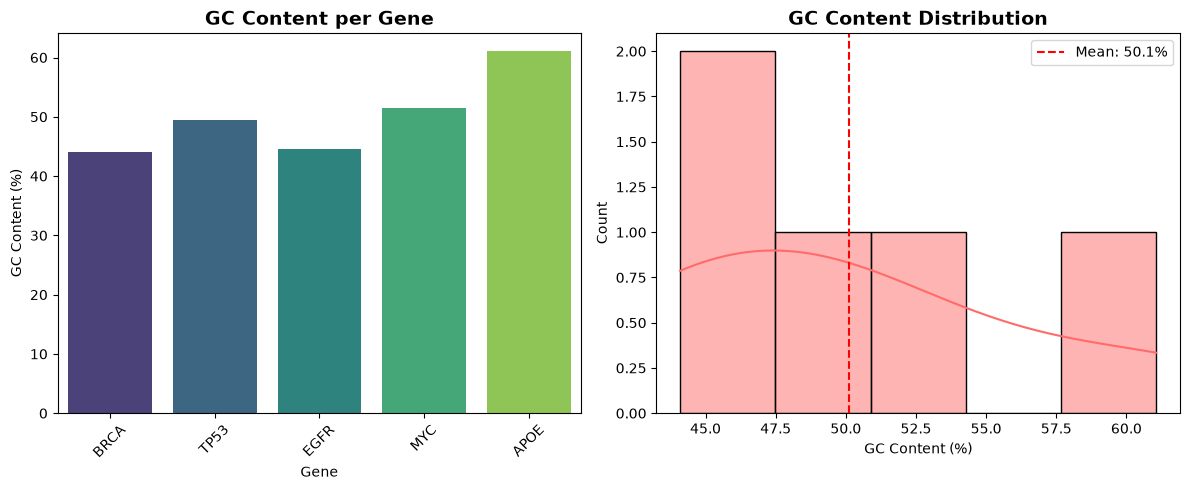


=== TASK 2: Pairwise Sequence Alignment ===
Comparing BRCA1 vs TP53...

Sequence 1: BRCA - Length: 126033
Sequence 2: TP53 - Length: 19070

Alignment Score: 524.2
Alignment Length: 687

--- Top Alignment (First 60 bases) ---
CTT------TCT---GTC--CCGCCCTTCC----------T--CTGACTGTG--TCTT----GA---TTT-CCTA-TT----CTGAG-AG---GCTATTGCTCA-G-CGGT-------TTCC--G---TGGCAACAGTAAAGC----G--TGGGAA-TTACAGATAA-A-T--TAAAACTG-TGGA---AC---CCCTTTCCTCGGCTGCCGCCAAGGTG----TTC-GGTCCTTCCGAGGAA----GCTAAGGCCG-CGTTGGGG-TG----AGACCCTC----ACTT--C-A-TCC-----GGTGAGTAGCACCGCG-TCCGGCAGCCCCAGCCCCACACTCGCCC-GCGCT--ATGGCCTCCG-TC-TCCC-----AGCTTGCC--TGCATCT----

=== Alignment Stats ===
Matches: 313
Identity: 45.56%
Gaps: 374


In [5]:
from Bio import pairwise2
from Bio.pairwise2 import format_alignment
from Bio.SeqUtils import gc_fraction 
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


print("=== TASK 1: GC Content Distribution ===")


gc_values = []
for seq in gene_sequences:
    gc_values.append(gc_fraction(seq.seq) * 100) 


gc_df = pd.DataFrame({
    'Gene': gene_names,
    'GC_Content': gc_values,
    'Sequence_Length': [len(seq.seq) for seq in gene_sequences]
})

print(gc_df)


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
sns.barplot(data=gc_df, x='Gene', y='GC_Content', palette='viridis')
plt.title('GC Content per Gene', fontsize=14, fontweight='bold')
plt.ylabel('GC Content (%)')
plt.xticks(rotation=45)


plt.subplot(1, 2, 2)
sns.histplot(gc_df['GC_Content'], bins=5, kde=True, color='#FF6B6B')
plt.title('GC Content Distribution', fontsize=14, fontweight='bold')
plt.xlabel('GC Content (%)')
plt.axvline(gc_df['GC_Content'].mean(), color='red', linestyle='--', label=f"Mean: {gc_df['GC_Content'].mean():.1f}%")
plt.legend()

plt.tight_layout()
plt.show()


print("\n=== TASK 2: Pairwise Sequence Alignment ===")
print("Comparing BRCA1 vs TP53...\n")


seq1 = gene_sequences[0].seq 
seq2 = gene_sequences[1].seq 


seq1_short = seq1[:500]
seq2_short = seq2[:500]


alignments = pairwise2.align.globalms(seq1_short, seq2_short, 2, -1, -0.5, -0.1)


print(f"Sequence 1: {gene_names[0]} - Length: {len(seq1)}")
print(f"Sequence 2: {gene_names[1]} - Length: {len(seq2)}")
print(f"\nAlignment Score: {alignments[0].score:.1f}")
print(f"Alignment Length: {len(alignments[0].seqA)}")
print("\n--- Top Alignment (First 60 bases) ---")
print(format_alignment(*alignments[0])[:400]) 


matches = sum(a == b for a, b in zip(alignments[0].seqA, alignments[0].seqB) if a!= '-' and b!= '-')
alignment_length = len(alignments[0].seqA)
identity = (matches / alignment_length) * 100

print(f"\n=== Alignment Stats ===")
print(f"Matches: {matches}")
print(f"Identity: {identity:.2f}%")
print(f"Gaps: {alignments[0].seqA.count('-') + alignments[0].seqB.count('-')}")

=== WEEK 5: Gene Expression Analysis ===
=== Raw Expression Data ===
        Cancer_1  Cancer_2  Cancer_3  Normal_1  Normal_2  Normal_3
Gene                                                              
BRCA1        120       115       125        40        35        45
TP53          85        90        80       150       160       155
EGFR         200       210       195        80        75        85
MYC          340       360       330       100        95       105
APOE          50        55        48        45        50        42
GAPDH        500       520       510       480       490       485
ACTB         480       490       470       460       450       465
TUBA1A       300       310       295       280       290       285
BCL2          90        85        95       140       150       145
PTEN         110       105       115       180       190       185

=== Mean Expression per Gene ===
        Cancer_Mean  Normal_Mean  Overall_Mean
Gene                                          

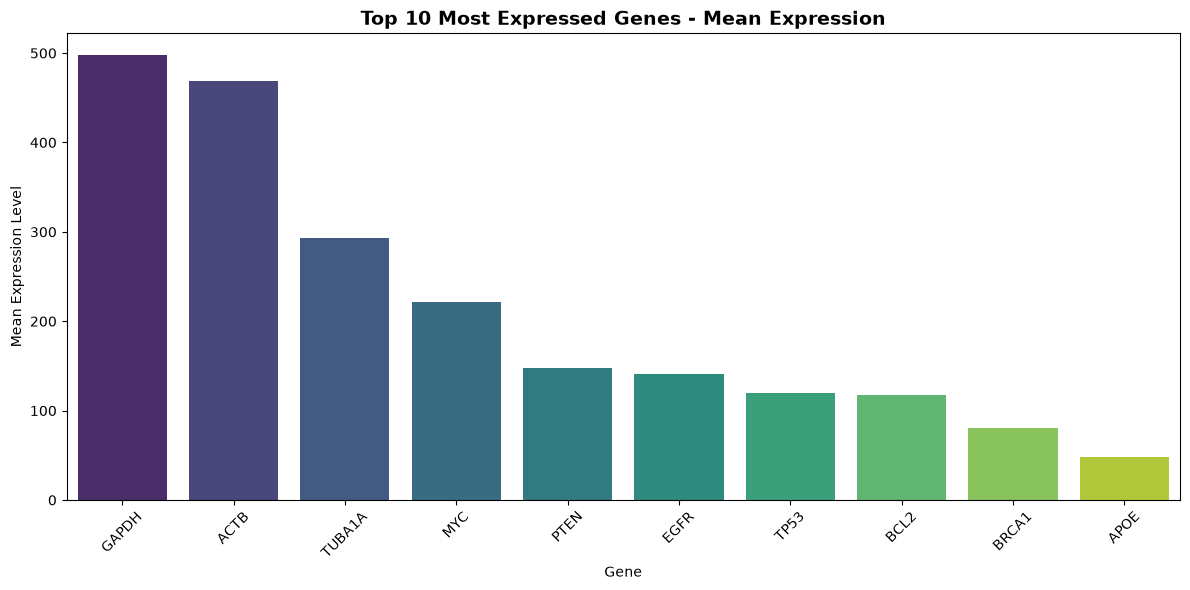

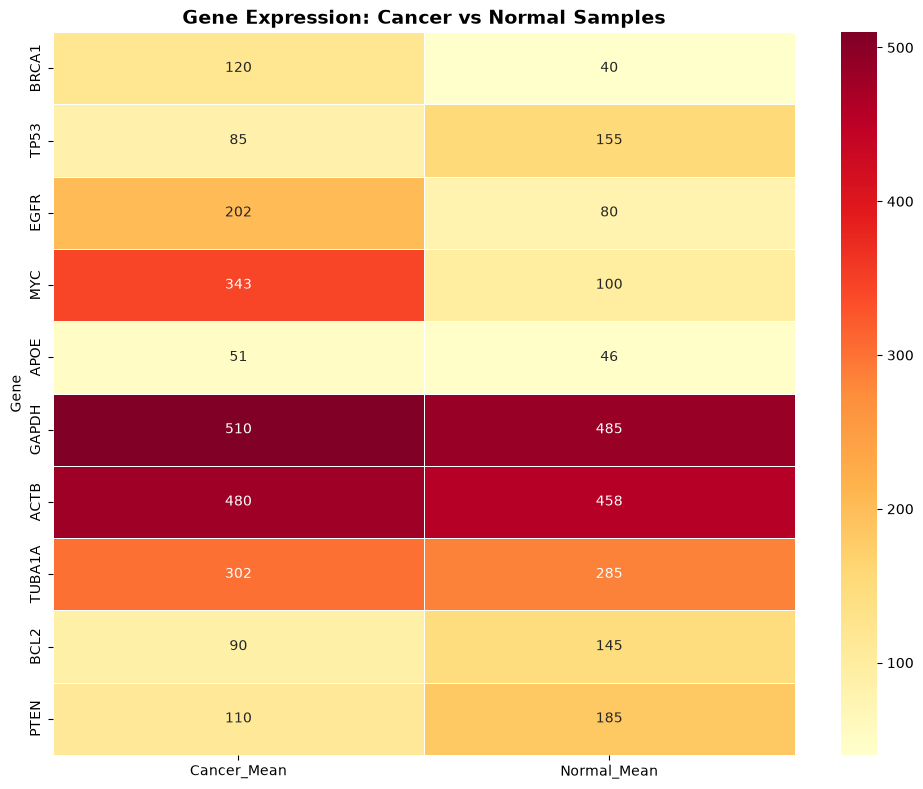

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("=== WEEK 5: Gene Expression Analysis ===")


data = {
    'Gene': ['BRCA1', 'TP53', 'EGFR', 'MYC', 'APOE', 'GAPDH', 'ACTB', 'TUBA1A', 'BCL2', 'PTEN'],
    'Cancer_1': [120, 85, 200, 340, 50, 500, 480, 300, 90, 110],
    'Cancer_2': [115, 90, 210, 360, 55, 520, 490, 310, 85, 105],
    'Cancer_3': [125, 80, 195, 330, 48, 510, 470, 295, 95, 115],
    'Normal_1': [40, 150, 80, 100, 45, 480, 460, 280, 140, 180],
    'Normal_2': [35, 160, 75, 95, 50, 490, 450, 290, 150, 190],
    'Normal_3': [45, 155, 85, 105, 42, 485, 465, 285, 145, 185]
}

expr_df = pd.DataFrame(data)
expr_df.set_index('Gene', inplace=True)
print("=== Raw Expression Data ===")
print(expr_df)


expr_df['Cancer_Mean'] = expr_df[['Cancer_1', 'Cancer_2', 'Cancer_3']].mean(axis=1)
expr_df['Normal_Mean'] = expr_df[['Normal_1', 'Normal_2', 'Normal_3']].mean(axis=1)
expr_df['Overall_Mean'] = expr_df[['Cancer_Mean', 'Normal_Mean']].mean(axis=1)

print("\n=== Mean Expression per Gene ===")
print(expr_df[['Cancer_Mean', 'Normal_Mean', 'Overall_Mean']].round(2))


top10 = expr_df.sort_values('Overall_Mean', ascending=False).head(10)
print("\n=== TOP 10 Most Expressed Genes ===")
print(top10[['Overall_Mean']].round(2))


plt.figure(figsize=(12, 6))
sns.barplot(x=top10.index, y=top10['Overall_Mean'], hue=top10.index, palette='viridis', legend=False)
plt.title('Top 10 Most Expressed Genes - Mean Expression', fontsize=14, fontweight='bold')
plt.ylabel('Mean Expression Level')
plt.xlabel('Gene')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 8))
plot_data = expr_df[['Cancer_Mean', 'Normal_Mean']]
sns.heatmap(plot_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Gene Expression: Cancer vs Normal Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== WEEK 6: t-tests + Volcano Plot ===
=== t-test Results ===
     Gene  log2FC  p_value  neg_log10_p
0   BRCA1    1.58    0.000        4.398
1    TP53   -0.87    0.000        4.168
2    EGFR    1.33    0.000        4.681
3     MYC    1.78    0.000        4.901
4    APOE    0.16    0.163        0.787
5   GAPDH    0.07    0.018        1.746
6    ACTB    0.07    0.041        1.391
7  TUBA1A    0.08    0.034        1.467
8    BCL2   -0.69    0.000        3.755
9    PTEN   -0.75    0.000        4.287


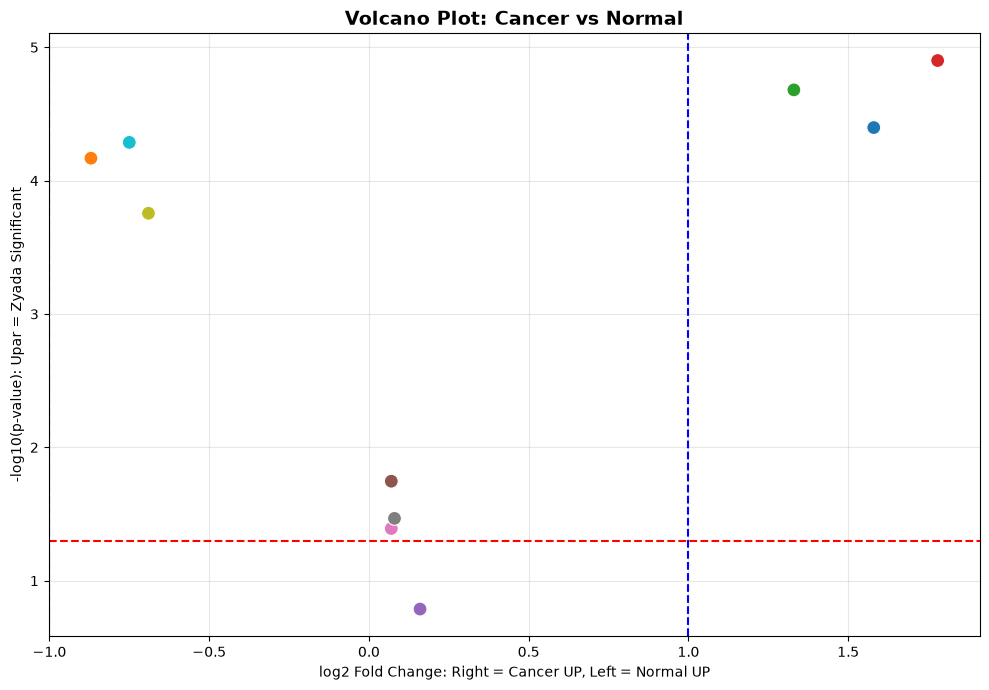


=== Significant Differentially Expressed Genes ===
p < 0.05 aur |log2FC| > 1:
    Gene  log2FC   p_value
0  BRCA1    1.58  0.000040
2   EGFR    1.33  0.000021
3    MYC    1.78  0.000013


In [7]:
from scipy import stats
import numpy as np

print("=== WEEK 6: t-tests + Volcano Plot ===")


results = []

for gene in expr_df.index:
    cancer_vals = expr_df.loc[gene, ['Cancer_1', 'Cancer_2', 'Cancer_3']].values
    normal_vals = expr_df.loc[gene, ['Normal_1', 'Normal_2', 'Normal_3']].values
    
    
    t_stat, p_val = stats.ttest_ind(cancer_vals, normal_vals)
    
    
    fc = expr_df.loc[gene, 'Cancer_Mean'] / expr_df.loc[gene, 'Normal_Mean']
    log2fc = np.log2(fc)
    
    results.append({
        'Gene': gene,
        'log2FC': round(log2fc, 2),
        'p_value': p_val,
        'neg_log10_p': -np.log10(p_val)
    })

stats_df = pd.DataFrame(results)
print("=== t-test Results ===")
print(stats_df.round(3))


plt.figure(figsize=(10, 7))
sns.scatterplot(data=stats_df, x='log2FC', y='neg_log10_p', hue='Gene', s=100, legend=False)


plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='p=0.05')
plt.axvline(1, color='blue', linestyle='--')
plt.axvline(-1, color='blue', linestyle='--')

plt.title('Volcano Plot: Cancer vs Normal', fontsize=14, fontweight='bold')
plt.xlabel('log2 Fold Change: Right = Cancer UP, Left = Normal UP')
plt.ylabel('-log10(p-value): Upar = Zyada Significant')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


sig_genes = stats_df[(stats_df['p_value'] < 0.05) & (abs(stats_df['log2FC']) > 1)]
print("\n=== Significant Differentially Expressed Genes ===")
print("p < 0.05 aur |log2FC| > 1:")
print(sig_genes[['Gene', 'log2FC', 'p_value']])









Protein Composition Analysis: Human vs E. coli
Loaded: BRCA1_Human - 1863 AA
Loaded: TP53_Human - 393 AA
Loaded: EGFR_Human - 1210 AA
Loaded: MYC_Human - 454 AA
Loaded: APOE_Human - 317 AA
Loaded: RecA_Ecoli - 353 AA
Loaded: RpoB_Ecoli - 1342 AA
Loaded: FtsZ_Ecoli - 383 AA

=== Length Summary ===
                  Type  Length
Protein                       
BRCA1_Human      Human    1863
RpoB_Ecoli   Bacterial    1342
EGFR_Human       Human    1210
MYC_Human        Human     454
TP53_Human       Human     393
FtsZ_Ecoli   Bacterial     383
RecA_Ecoli   Bacterial     353
APOE_Human       Human     317


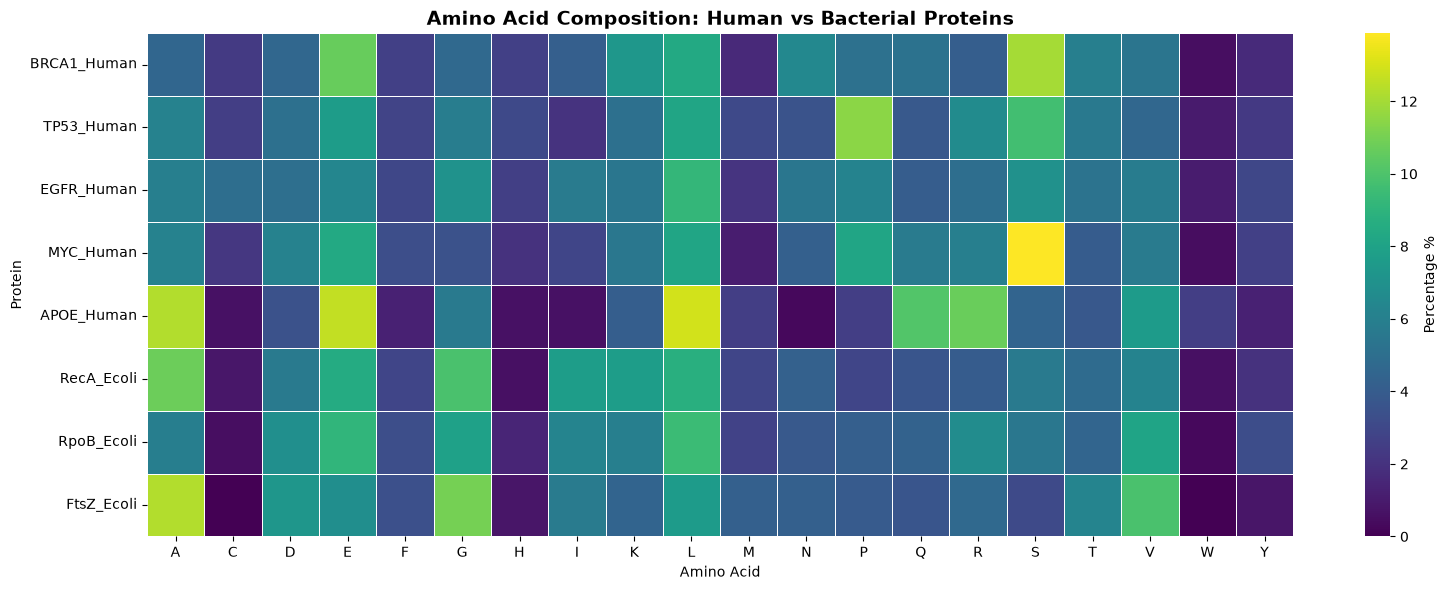

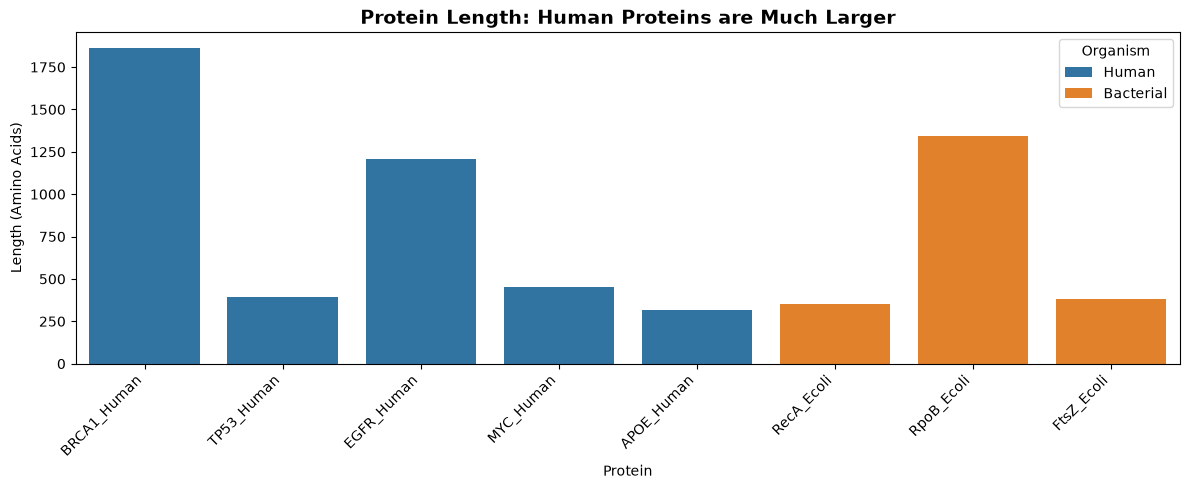


=== Average Properties: Human vs Bacterial ===
           %_Hydrophobic  %_Charged  %_Polar  Length
Type                                                
Bacterial           41.6       26.8     18.4   692.7
Human               33.2       28.1     26.6   847.4


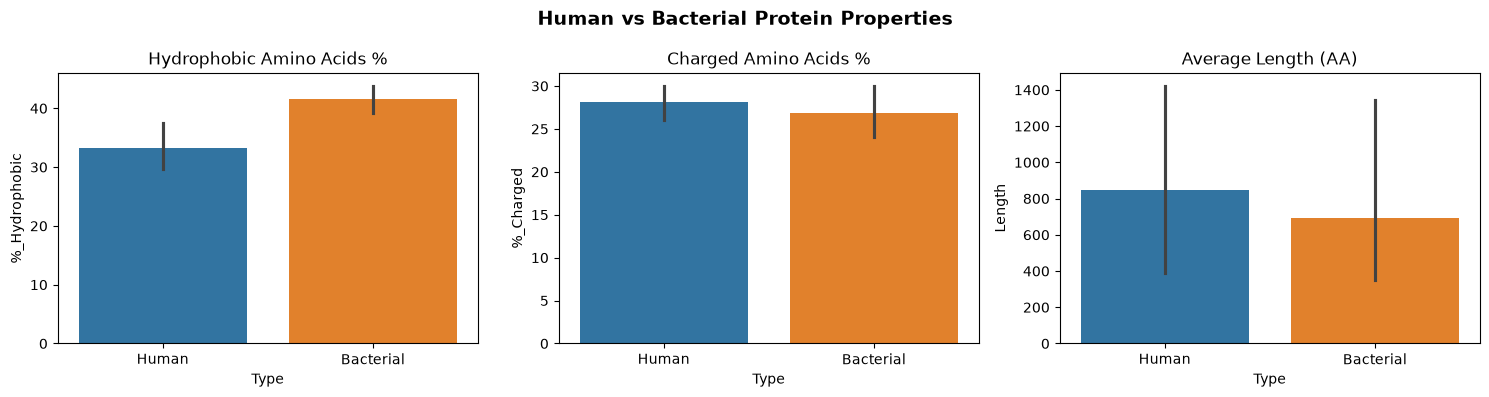

In [8]:
from Bio import ExPASy, SeqIO
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

print("Protein Composition Analysis: Human vs E. coli")


human_proteins = {
    'BRCA1_Human': 'P38398',
    'TP53_Human': 'P04637',
    'EGFR_Human': 'P00533',
    'MYC_Human': 'P01106',
    'APOE_Human': 'P02649'
}


bacterial_proteins = {
    'RecA_Ecoli': 'P0A7G6', 
    'RpoB_Ecoli': 'P0A8V2', 
    'FtsZ_Ecoli': 'P0A9A6' 
}

all_proteins = {**human_proteins, **bacterial_proteins}
protein_records = {}
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")


for name, uid in all_proteins.items():
    try:
        handle = ExPASy.get_sprot_raw(uid)
        record = SeqIO.read(handle, 'swiss')
        protein_records[name] = record
        print(f"Loaded: {name} - {len(record.seq)} AA")
    except Exception as e:
        print(f"Error loading {name}: {e}")


composition_data = []
for name, record in protein_records.items():
    seq = str(record.seq)
    counts = Counter(seq)
    total = len(seq)
    row = {'Protein': name, 'Length': total, 'Type': 'Human' if 'Human' in name else 'Bacterial'}
    for aa in amino_acids:
        row[aa] = round((counts.get(aa, 0) / total) * 100, 2)
    composition_data.append(row)

comp_df = pd.DataFrame(composition_data).set_index('Protein')
print("\n=== Length Summary ===")
print(comp_df[['Type', 'Length']].sort_values('Length', ascending=False))


plt.figure(figsize=(16, 6))
sns.heatmap(comp_df[amino_acids], annot=False, cmap='viridis', linewidths=0.5, cbar_kws={'label': 'Percentage %'})
plt.title('Amino Acid Composition: Human vs Bacterial Proteins', fontsize=14, fontweight='bold')
plt.ylabel('Protein')
plt.xlabel('Amino Acid')
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))
sns.barplot(data=comp_df.reset_index(), x='Protein', y='Length', hue='Type',
            palette={'Human':'#1f77b4', 'Bacterial':'#ff7f0e'}, dodge=False)
plt.title('Protein Length: Human Proteins are Much Larger', fontsize=14, fontweight='bold')
plt.ylabel('Length (Amino Acids)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Organism')
plt.tight_layout()
plt.show()


hydrophobic = ['A', 'V', 'I', 'L', 'M', 'F', 'W', 'Y']
charged = ['D', 'E', 'K', 'R', 'H']
polar = ['S', 'T', 'N', 'Q', 'C']

comp_df['%_Hydrophobic'] = comp_df[hydrophobic].sum(axis=1)
comp_df['%_Charged'] = comp_df[charged].sum(axis=1)
comp_df['%_Polar'] = comp_df[polar].sum(axis=1)


grouped = comp_df.groupby('Type')[['%_Hydrophobic', '%_Charged', '%_Polar', 'Length']].mean().round(1)
print("\n=== Average Properties: Human vs Bacterial ===")
print(grouped)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=comp_df.reset_index(), x='Type', y='%_Hydrophobic', hue='Type',
            palette={'Human':'#1f77b4', 'Bacterial':'#ff7f0e'}, ax=axes[0], legend=False)
axes[0].set_title('Hydrophobic Amino Acids %')

sns.barplot(data=comp_df.reset_index(), x='Type', y='%_Charged', hue='Type',
            palette={'Human':'#1f77b4', 'Bacterial':'#ff7f0e'}, ax=axes[1], legend=False)
axes[1].set_title('Charged Amino Acids %')

sns.barplot(data=comp_df.reset_index(), x='Type', y='Length', hue='Type',
            palette={'Human':'#1f77b4', 'Bacterial':'#ff7f0e'}, ax=axes[2], legend=False)
axes[2].set_title('Average Length (AA)')

plt.suptitle('Human vs Bacterial Protein Properties', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== WEEK 8: K-means Clustering + PCA ===
Gene Expression Data:
        Normal_1   Normal_2   Normal_3   Normal_4   Normal_5  Cancer_1  \
BRCA1  12.142530   6.434896  14.121360  33.886946   5.846520  5.846616   
TP53   13.016291  12.986231  26.352989   3.053655   3.686589  4.211052   
EGFR   31.997212   5.895703   7.905259   1.777578   4.287129  8.255855   
MYC     4.048285  47.100244   7.289994   2.565848  16.819601  7.628714   
PTEN   15.463255   8.770276   6.582086   5.467909   1.684516  3.597200   

        Cancer_2   Cancer_3   Cancer_4   Cancer_5  
BRCA1  35.845313  15.917748   4.620605  12.712173  
TP53    2.683626  10.117305   2.980157   1.799837  
EGFR    2.337323  10.758520   4.052611   5.519605  
MYC    31.868771   3.644040   6.852249  31.488557  
PTEN    4.661612  21.266270  10.418867   1.267390  

=== K-means Clusters ===
          Cluster Sample_Type
Normal_1        1      Normal
Normal_2        2      Normal
Normal_3        1      Normal
Normal_4        2      Normal
Norm

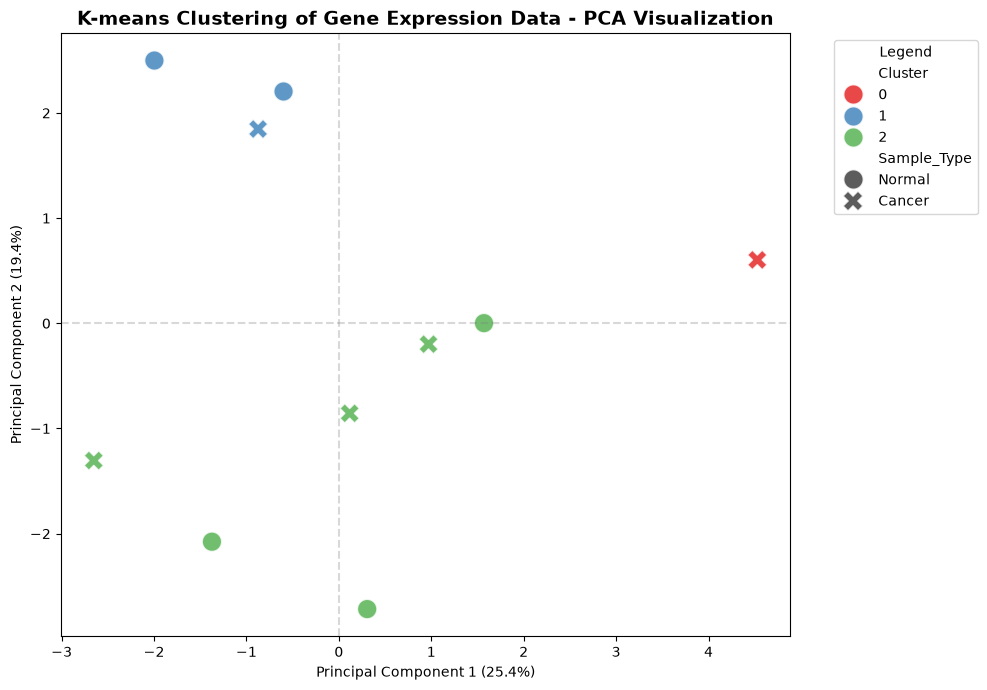


 Gene Expression Clustering Analysis
    MYC  TP53  GAPDH
0 -0.56 -0.53   0.03
1 -0.74  1.14  -0.41
2  0.47 -0.48   0.20


In [2]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=== WEEK 8: K-means Clustering + PCA ===")


np.random.seed(42)
genes = ['BRCA1', 'TP53', 'EGFR', 'MYC', 'PTEN', 'AKT1', 'PIK3CA', 'KRAS', 'BCL2', 'VEGFA',
         'GAPDH', 'ACTB', 'TUBA1A', 'HPRT1', 'RPL13A']


expression_data = np.random.lognormal(mean=2, sigma=1, size=(15, 10))
expression_data[3, 5:10] *= 3.5 
expression_data[1, 0:5] *= 2.8 
expression_data[10:15, :] += 4 

exp_df = pd.DataFrame(expression_data, index=genes,
                      columns=[f'Normal_{i+1}' for i in range(5)] + [f'Cancer_{i+1}' for i in range(5)])

print("Gene Expression Data:")
print(exp_df.head())
scaler = StandardScaler()
exp_scaled = scaler.fit_transform(exp_df.T) 
exp_scaled_df = pd.DataFrame(exp_scaled, columns=exp_df.index,
                             index=exp_df.columns)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(exp_scaled)
exp_scaled_df['Cluster'] = clusters
exp_scaled_df['Sample_Type'] = ['Normal']*5 + ['Cancer']*5

print("\n=== K-means Clusters ===")
print(exp_scaled_df[['Cluster', 'Sample_Type']])

pca = PCA(n_components=2) 
pca_result = pca.fit_transform(exp_scaled)
exp_scaled_df['PCA1'] = pca_result[:, 0]
exp_scaled_df['PCA2'] = pca_result[:, 1]

print(f"\nPCA Explained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"PC1: {pca.explained_variance_ratio_[0]*100:.1f}%, PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")

plt.figure(figsize=(10, 7))
sns.scatterplot(data=exp_scaled_df, x='PCA1', y='PCA2',
                hue='Cluster', style='Sample_Type',
                palette='Set1', s=200, alpha=0.8)
plt.title('K-means Clustering of Gene Expression Data - PCA Visualization',
          fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.axhline(0, color='grey', linestyle='--', alpha=0.3)
plt.axvline(0, color='grey', linestyle='--', alpha=0.3)
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=exp_df.index)
print("\n Gene Expression Clustering Analysis")
print(cluster_centers[['MYC', 'TP53', 'GAPDH']].round(2))

 Disease Classification using Gene Expression
Dataset Shape: (10, 15)
Samples: ['Normal_1', 'Normal_2', 'Normal_3', 'Normal_4', 'Normal_5', 'Cancer_1', 'Cancer_2', 'Cancer_3', 'Cancer_4', 'Cancer_5']
Labels: ['Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Cancer', 'Cancer', 'Cancer', 'Cancer', 'Cancer']

Training samples: 7, Testing samples: 3

=== Random Forest Results ===
              precision    recall  f1-score   support

      Cancer       0.50      0.50      0.50         2
      Normal       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3

Accuracy: 33.3%


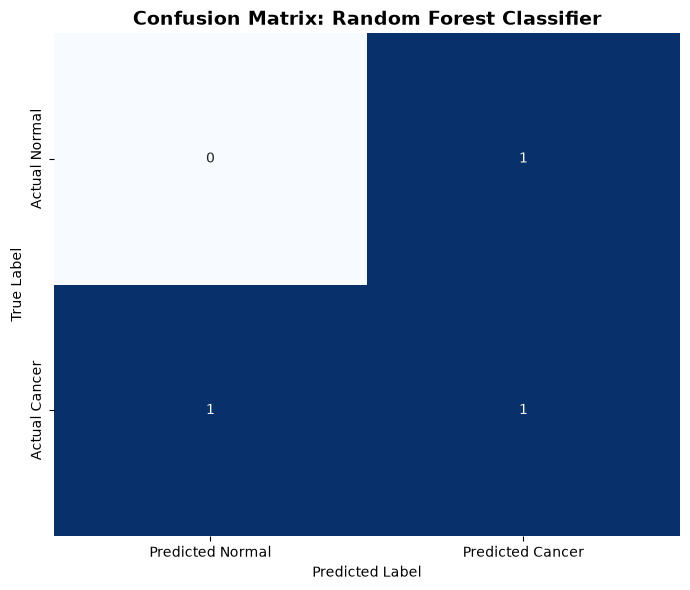

C:\Users\Ahmad\AppData\Local\Temp\ipykernel_6988\1068700157.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp, x='Importance', y='Gene', palette='viridis')


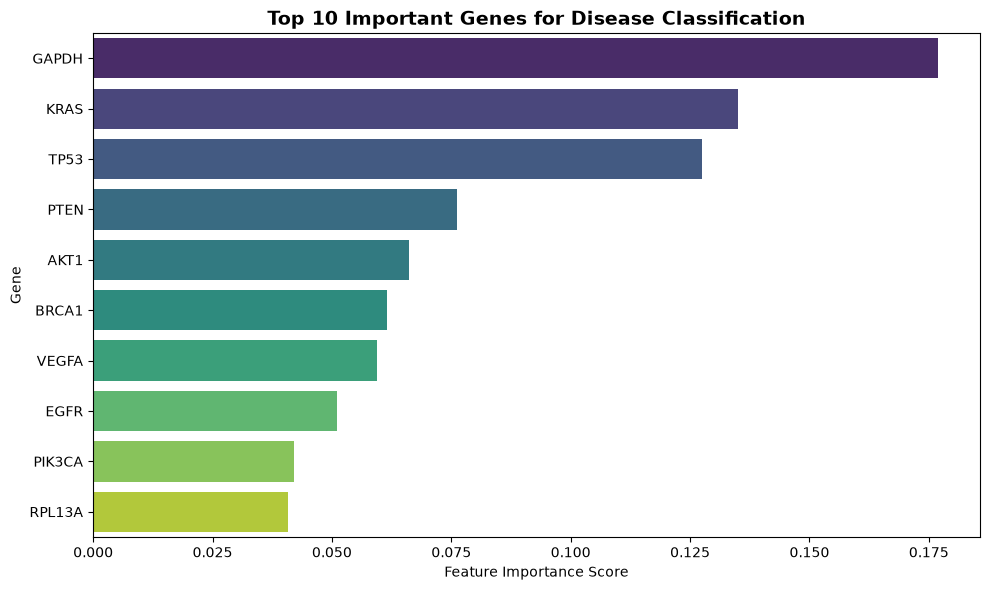


=== Top 5 Predictive Genes ===
     Gene  Importance
10  GAPDH    0.176871
7    KRAS    0.135034
1    TP53    0.127594
4    PTEN    0.076190
5    AKT1    0.066156

=== Logistic Regression Results ===
              precision    recall  f1-score   support

      Cancer       0.00      0.00      0.00       2.0
      Normal       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0

Accuracy: 0.0%


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print(" Disease Classification using Gene Expression")

np.random.seed(42)
genes = ['BRCA1', 'TP53', 'EGFR', 'MYC', 'PTEN', 'AKT1', 'PIK3CA', 'KRAS', 'BCL2', 'VEGFA',
         'GAPDH', 'ACTB', 'TUBA1A', 'HPRT1', 'RPL13A']

expression_data = np.random.lognormal(mean=2, sigma=1, size=(15, 10))
expression_data[3, 5:10] *= 4.0 
expression_data[1, 0:5] *= 3.0 
expression_data[10:15, :] += 5 

exp_df = pd.DataFrame(expression_data, index=genes,
                      columns=[f'Normal_{i+1}' for i in range(5)] + [f'Cancer_{i+1}' for i in range(5)])

X = exp_df.T  
y = ['Normal']*5 + ['Cancer']*5  

print("Dataset Shape:", X.shape)
print("Samples:", X.index.tolist())
print("Labels:", y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"\nTraining samples: {len(X_train)}, Testing samples: {len(X_test)}")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)

print("\n=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf, target_names=['Cancer', 'Normal']))
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.1f}%")
cm = confusion_matrix(y_test, y_pred_rf, labels=['Normal', 'Cancer'])
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Cancer'],
            yticklabels=['Actual Normal', 'Actual Cancer'])
plt.title('Confusion Matrix: Random Forest Classifier', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

feature_imp = pd.DataFrame({
    'Gene': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_imp, x='Importance', y='Gene', palette='viridis')
plt.title('Top 10 Important Genes for Disease Classification', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print("\n=== Top 5 Predictive Genes ===")
print(feature_imp.head())

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("\n=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_lr, target_names=['Cancer', 'Normal']))
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.1f}%")